<div style="
  width: 100%;
  background-color: #0A2A43;
  color: white;
  padding: 16px 24px;
  box-sizing: border-box;
  font-weight: bold;
  font-size: 1.4rem;
">
  JOSÉ MESSIAS GARCIA DA SILVA FERREIRA
</div>


<div style="
  width: 100%;
  background-color: #0A2A43;
  color: white;
  padding: 16px 24px;
  box-sizing: border-box;
  font-weight: bold;
  font-size: 1.4rem;
">
  SPRINT_11
</div>


### Descripción
Esta práctica integra el uso de Python con las librerías Pandas, Matplotlib, Seaborn o Plotly, así como su integración con Power BI. Trabajarás todo el proceso desde la conexión a MySQL, la creación de visualizaciones avanzadas en Python y, finalmente, la incorporación de estas visualizaciones en un informe dinámico en Power BI.

<div style="
  width: 100%;
  background-color: #0A2A43;
  color: white;
  padding: 16px 24px;
  box-sizing: border-box;
  font-weight: bold;
  font-size: 1.4rem;
">
  Nivel 1
</div>


1. Conecta Python con MySQL Workbench y carga los datos de tu base de datos del Sprint 4 para utilizarlos en todos los ejercicios.

In [ ]:
# datos y cálculo
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# visualización
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker
import seaborn as sns
import plotly
import plotly.graph_objects as go
import plotly.express as px

# grafo / redes
import networkx as nx

# base de datos
import mysql.connector
from mysql.connector import Error

In [ ]:
config = {
    'host': 'localhost',
    'user': 'root',
    'password': '1234',
    'database': 'my_store'
}

conn = mysql.connector.connect(**config)
cursor = conn.cursor()

cursor.execute("SELECT database();")
db_actual = cursor.fetchone()[0]
print(f"--- Conectado a la base de datos: {db_actual} ---")

cursor.execute("SHOW TABLES;")
tablas = cursor.fetchall()

dataframes = {}

print("Tablas encontradas:")
for (tabla,) in tablas:
    print(f"- {tabla}")
    dataframes[tabla] = pd.read_sql(
        f"SELECT * FROM {tabla}", conn
    )

transactions = dataframes['transactions']
users = dataframes['users']
products = dataframes['products']
companies = dataframes['companies']
transactions_products = dataframes['transactions_products']
credit_cards= dataframes['credit_cards']

--- Conectado a la base de datos: my_store ---
Tablas encontradas:
- companies


C:\Users\josemessiasferreira\AppData\Local\Temp\ipykernel_4716\2243459218.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dataframes[tabla] = pd.read_sql(


- credit_cards
- products
- transactions
- transactions_products
- users


````
print("Tablas encontradas:") for t in tablas: print(f"{t[0]}") 
globals()[t[0]] = pd.read_sql("SELECT * FROM " + t[0], conn)

__________________________________________________________________

- 📊 Si la variable es **numérica** → generar un *histograma* o *boxplot*  
- 🏷️ Si es **categórica** → generar un gráfico de *barras* con los valores más frecuentes  
- 📅 Si es una **fecha** → generar un gráfico de *barras* con los años más frecuentes  


2. Para cada ítem, crea una visualización adecuada según las variables especificadas. Interpreta los resultados según tus datos.

Recuerda: cuando selecciones las columnas, piensa siempre en el método que vas a usar e incluye las que sean necesarias para la función de visualización que quieras utilizar.

<div style="
  border-left: 6px solid #4A7D6E;
  background-color: #4A7D6E;
  color: #080303;
  padding: 8px 16px;
  font-weight: bold;
  font-size: 1.1rem;
  margin-top: 20px;
">
  Una variable numérica
</div>

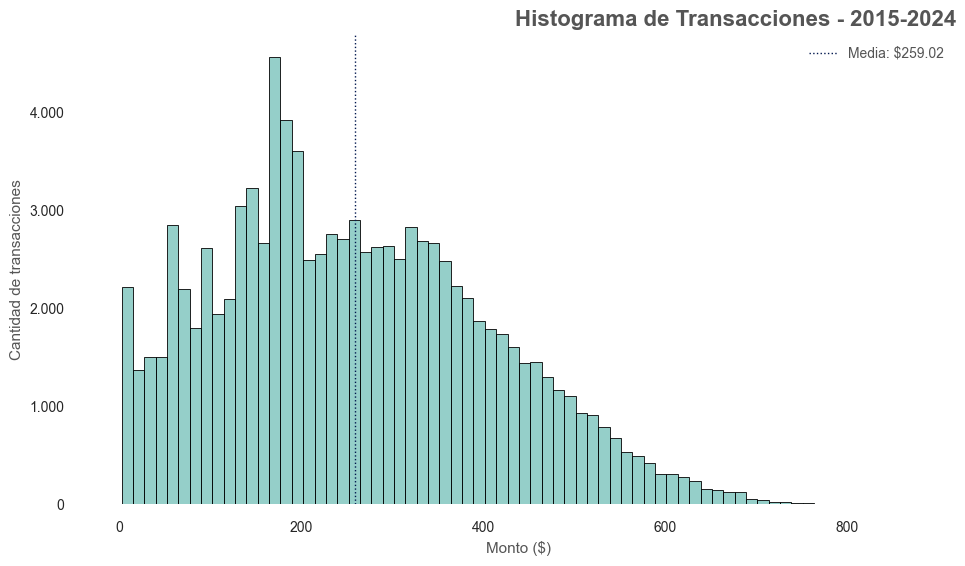

In [ ]:
sns.set_theme(style="white")
sns.set_context("talk")
plt.figure(figsize=(10,6))

bar_color = "#69BBB3"

sns.histplot(
    transactions['amount'].dropna(),
    bins=70,
    alpha=0.7,
    color=bar_color, 
    edgecolor="black", 
    linewidth=0.6, 
)

mu = transactions['amount'].mean()

plt.axvline(
    mu,
    color="#01174E",
    linestyle='dotted',
    linewidth=1,
    label=f"Media: ${mu:,.2f}"
)

plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))

plt.title("Histograma de Transacciones - 2015-2024", fontsize=16, weight="bold", loc="right", color="#555555")
plt.xlabel("Monto ($)", fontsize=11, color="#555555")
plt.ylabel("Cantidad de transacciones", fontsize=11, color="#555555")
plt.legend(frameon=False, labelcolor="#555555", fontsize=10)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

<div style="padding: 20px; border-left: 8px solid #4A7D6E; background-color: #f4f9f7; border-radius: 5px; color: #333333; font-family: 'Arial', sans-serif; line-height: 1.6;">
    <h3 style="color: #4A7D6E; margin-top: 0;">📌 Distribución de Transacciones</h3>
    Este gráfico nos muestra que el negocio tiene dos mundos: la gran mayoría de nuestros clientes realiza compras pequeñas (entre $150 y $200), pero tenemos un grupo selecto de clientes premium que gasta mucho más. Son precisamente estas compras altas las que hacen que el promedio suba hasta los $259, aunque no sea lo que gasta el cliente común. En resumen, el volumen de ventas viene de los precios bajos, pero la riqueza del promedio la aportan nuestros clientes VIP.
</div>

<div style="
  border-left: 6px solid #4A7D6E;
  background-color: #4A7D6E;
  color: #080303;
  padding: 8px 16px;
  font-weight: bold;
  font-size: 1.1rem;
  margin-top: 20px;
">
  Dos variables numéricas
</div>

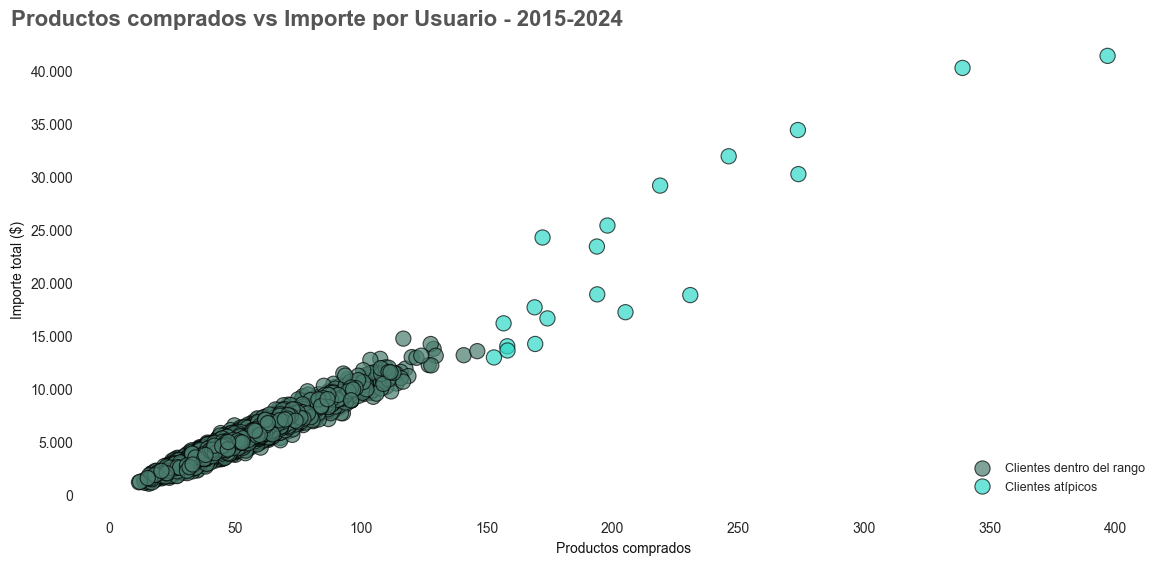

In [ ]:
prod_count = transactions_products.merge(
    transactions[['id','user_id']], 
    left_on='transaction_id', 
    right_on='id'
).groupby('user_id').size().reset_index(name='productos_comprados')

importe_sum = transactions.groupby('user_id')['amount'].sum().reset_index(name='total_importe')

df_users = users.merge(prod_count, left_on='id', right_on='user_id', how='left')
df_users = df_users.merge(importe_sum, left_on='id', right_on='user_id', how='left')

df_users['productos_comprados'] = df_users['productos_comprados'].fillna(0)
df_users['total_importe'] = df_users['total_importe'].fillna(0)

df_users['tipo'] = 'Clientes dentro del rango'
df_users.loc[df_users['productos_comprados'] > 150, 'tipo'] = 'Clientes atípicos'

df_users['productos_jitter'] = df_users['productos_comprados'] + np.random.uniform(-0.3, 0.3, size=len(df_users))

sns.set_theme(style="white")
sns.set_context("talk")
plt.figure(figsize=(12,6))

palette = {
    'Clientes dentro del rango': "#4A7D6E",
    'Clientes atípicos': "#30D8C7"         
}
sns.scatterplot(
    data=df_users,
    x='productos_jitter',
    y='total_importe',
    hue='tipo',
    linewidth=0.8,
    palette=palette,
    edgecolor="#000000",
    s=120,
    alpha=0.7
)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))

plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)

plt.title(
    "Productos comprados vs Importe por Usuario - 2015-2024",
    fontsize=16,
    weight="bold",
    color="#555555",
    ha="right"
)

plt.xlabel("Productos comprados", fontsize=10, color="#121212")
plt.ylabel("Importe total ($)", fontsize=10, color="#121212")
plt.legend(title="",frameon=False, fontsize=9, loc="lower right")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

<div style="padding: 20px; border-left: 8px solid #4A7D6E; background-color: #f4f9f7; border-radius: 5px; color: #333333; font-family: 'Arial', sans-serif; line-height: 1.6;">
    <h3 style="color: #4A7D6E; margin-top: 0;">📊 Correlación: Importe vs. Volumen</h3>
    Este gráfico confirma que existe una relación directa: cuantos más productos compra un usuario, más dinero invierte en total. La mayoría de nuestros clientes (en verde oscuro) se amontonan al principio, comprando pocos productos por montos bajos. Sin embargo, los clientes atípicos (en turquesa) son los que realmente destacan, ya que se dispersan hacia la derecha y hacia arriba, mostrando que unos pocos usuarios son responsables por compras de mayor volumen y valor.
</div>

<div style="
  border-left: 6px solid #4A7D6E;
  background-color: #4A7D6E;
  color: #080303;
  padding: 8px 16px;
  font-weight: bold;
  font-size: 1.1rem;
  margin-top: 20px;
">
  Una variable categórica
</div>

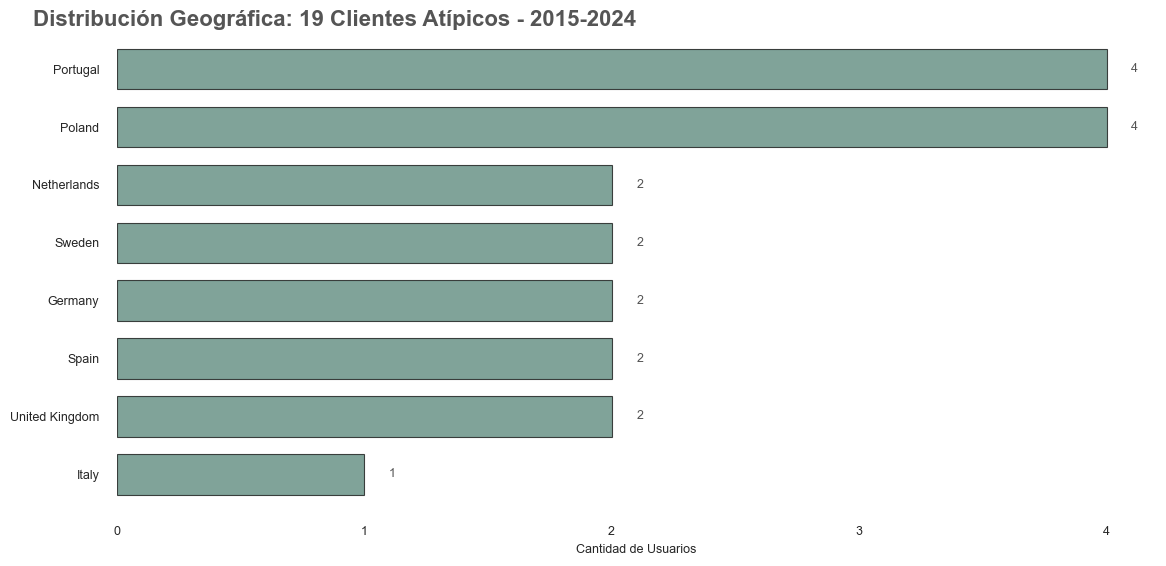

In [ ]:
df_atipicos = df_users[df_users['tipo'] == 'Clientes atípicos']
counts = df_atipicos['country'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(12, 6)) 

ax = counts.plot(
    kind='barh', 
    color="#4A7D6E",
    alpha=0.7, 
    edgecolor="black", 
    linewidth=0.8, 
    width=0.7
)

ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tick_params(axis='both', which='major', labelsize=9) 

for i, v in enumerate(counts):
    ax.text(v + 0.1, i, str(int(v)), color='#555555', va='center', fontsize=9)


plt.title(
    "Distribución Geográfica: 19 Clientes Atípicos - 2015-2024",
    fontsize=16,
    weight="bold",
    color="#555555",
    ha="right"
)

plt.xlabel("Cantidad de Usuarios", fontsize=9)
plt.ylabel("") 

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

<div style="padding: 20px; border-left: 8px solid #4A7D6E; background-color: #f4f9f7; border-radius: 5px; color: #333333; font-family: 'Arial', sans-serif; line-height: 1.6;">
    <h3 style="color: #4A7D6E; margin-top: 0;">🌍 Concentración Geográfica de Clientes Atípicos</h3>
    Al profundizar en estos 19 clientes atípicos, descubrimos que pertenecen exclusivamente al mercado europeo y Reino Unido. Este hallazgo es clave para diseñar estrategias de fidelización localizadas y logística prioritaria para este nicho de alto valor.
</div>

<div style="
  border-left: 6px solid #4A7D6E;
  background-color: #4A7D6E;
  color: #080303;
  padding: 8px 16px;
  font-weight: bold;
  font-size: 1.1rem;
  margin-top: 20px;
">
  Una variable categórica y una numérica.
</div>

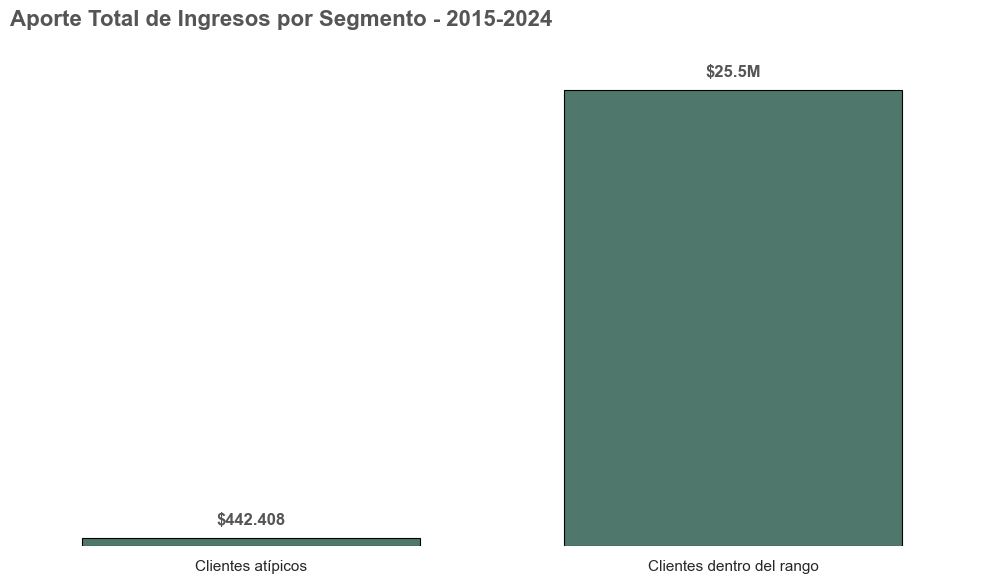

In [ ]:
sns.set_theme(style="white")

plt.figure(figsize=(10, 6))

ordem_invertida = ['Clientes atípicos', 'Clientes dentro del rango']

ax = sns.barplot(
    data=df_users, 
    x='tipo', 
    y='total_importe', 
    hue='tipo', 
    order=ordem_invertida,
    estimator=sum, 
    palette={'Clientes dentro del rango': "#4A7D6E", 'Clientes atípicos': "#4A7D6E"},
    errorbar=None,
    legend=False,
    edgecolor="black", 
    linewidth=0.8, 
    width=0.7
)

for p in ax.patches:
    if p.get_height() > 0:
        # Etiqueta: $25.4M si es grande, $442.000 si es pequeño
        if p.get_height() > 1e6:
            label = f'${p.get_height()/1e6:.1f}M'
        else:
            label = f'${p.get_height():,.0f}'.replace(',', '.')
        
        ax.annotate(
            label, 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', 
            va='baseline',
            xytext=(0, 10),           
            textcoords='offset points', 
            fontsize=12,             
            fontweight='bold', 
            color='#555555'            
        )

plt.title("Aporte Total de Ingresos por Segmento - 2015-2024", fontsize=16, weight='bold', color="#555555", pad=30, loc='left')

plt.xlabel("")
plt.ylabel("")
plt.yticks([]) 

sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()

<div style="padding: 20px; border-left: 8px solid #4A7D6E; background-color: #f4f9f7; border-radius: 5px; color: #333333; font-family: 'Arial', sans-serif; line-height: 1.6;">
    <h3 style="color: #4A7D6E; margin-top: 0;">💰 Contribución de Ingresos por Segmento</h3>
    A pesar de su alto valor individual, estos 19 clientes representan menos del 2% del volumen total de ingresos. Esto confirma que nuestra estabilidad financiera reside en los clientes comunes, lo que reduce el riesgo de dependencia de unos pocos compradores.
</div>

<div style="
  border-left: 6px solid #4A7D6E;
  background-color: #4A7D6E;
  color: #080303;
  padding: 8px 16px;
  font-weight: bold;
  font-size: 1.1rem;
  margin-top: 20px;
">
  Duas variables categóricas
</div>

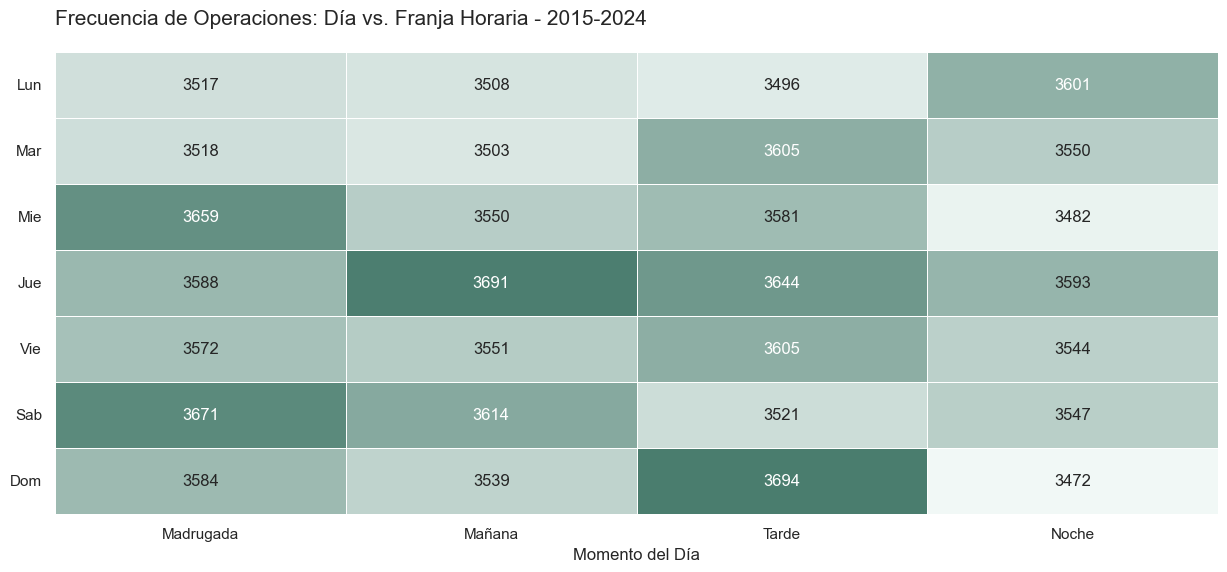

In [ ]:

def categorizar_hora(hora):
    """
    Transforma la hora numérica de una transacción en una categoría temporal (binning).
    
    Esta función permite agrupar datos de alta precisión (timestamps) en segmentos 
    lógicos para análisis de comportamiento humano y operativo.
    
    Parámetros:
    hora (int): Valor entero entre 0 y 23 que representa la hora del día.
    
    Retorna:
    str: Etiqueta de la franja horaria correspondiente:
         - 'Mañana': 06:00 a 11:59 (Horario de apertura y pico matutino)
         - 'Tarde': 12:00 a 17:59 (Horario de mayor actividad operativa)
         - 'Noche': 18:00 a 23:59 (Cierre de jornada y actividad nocturna)
         - 'Madrugada': 00:00 a 05:59 (Periodo de baja actividad manual/procesos automáticos)
    """
    if 6 <= hora < 12:
        return 'Mañana'
    elif 12 <= hora < 18:
        return 'Tarde'
    elif 18 <= hora < 24:
        return 'Noche'
    else:
        return 'Madrugada'

transactions['dia_nombre'] = transactions['timestamp'].dt.day_name()
transactions['dia_nombre'] = transactions['dia_nombre'].replace({
    'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miercoles', 
    'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
})

transactions['franja_horaria'] = transactions['timestamp'].dt.hour.apply(categorizar_hora)

tabla_frecuencia = pd.crosstab(transactions['dia_nombre'], transactions['franja_horaria'])

dias_ordenados = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
franjas_ordenadas = ['Madrugada', 'Mañana', 'Tarde', 'Noche']
tabla_frecuencia = tabla_frecuencia.reindex(index=dias_ordenados, columns=franjas_ordenadas)

custom_cmap = mcolors.LinearSegmentedColormap.from_list("mi_paleta", ["#F1F8F6", "#4A7D6E"]) 
            # modelo to convert colour arguments do RGB

plt.figure(figsize=(15, 6))
sns.heatmap(tabla_frecuencia, 
            annot=True, 
            fmt="d", 
            cmap=custom_cmap, # nuevo color
            cbar=False,
            linewidths=.5) 

plt.title("Frecuencia de Operaciones: Día vs. Franja Horaria - 2015-2024", 
          fontsize=15, weight='regular', loc='left', pad=20)

plt.xlabel("Momento del Día")
plt.yticks(np.arange(7) + 0.5, ["Lun", "Mar", "Mie", "Jue", "Vie", "Sab", "Dom"], rotation=0)
plt.ylabel("")

plt.show()

<div style=" padding: 20px; border-left: 8px solid #4A7D6E; background-color: #f4f9f7; border-radius: 5px; color: #333333; font-family: 'Arial', sans-serif; line-height: 1.6; "> <h3 style="color: #4A7D6E; margin-top: 0;">💡 Actividad</h3> <p> Lo primero que salta a la vista es que el ritmo de trabajo no para: procesamos más de <b>3.400 transaciones</b> constantes en cada franja horaria. Los momentos de mayor intensidad ocurren los <b>domingos por la tarde</b> y los <b>jueves por la mañana</b>. </p> <p> <b>La clave:</b> El equipo y el sistema están a pleno rendimiento, pero la cantidad de transacciones no siempre se traduce en llegar a la meta. Esto nos dice que el reto no es falta de actividad, sino que necesitamos que esas operaciones tengan un mayor valor para alcanzar los objetivos diarios. </p> </div>

<div style="
  border-left: 6px solid #4A7D6E;
  background-color: #4A7D6E;
  color: #080303;
  padding: 8px 16px;
  font-weight: bold;
  font-size: 1.1rem;
  margin-top: 20px;
">
  Una variable categórica y una numérica.
</div>

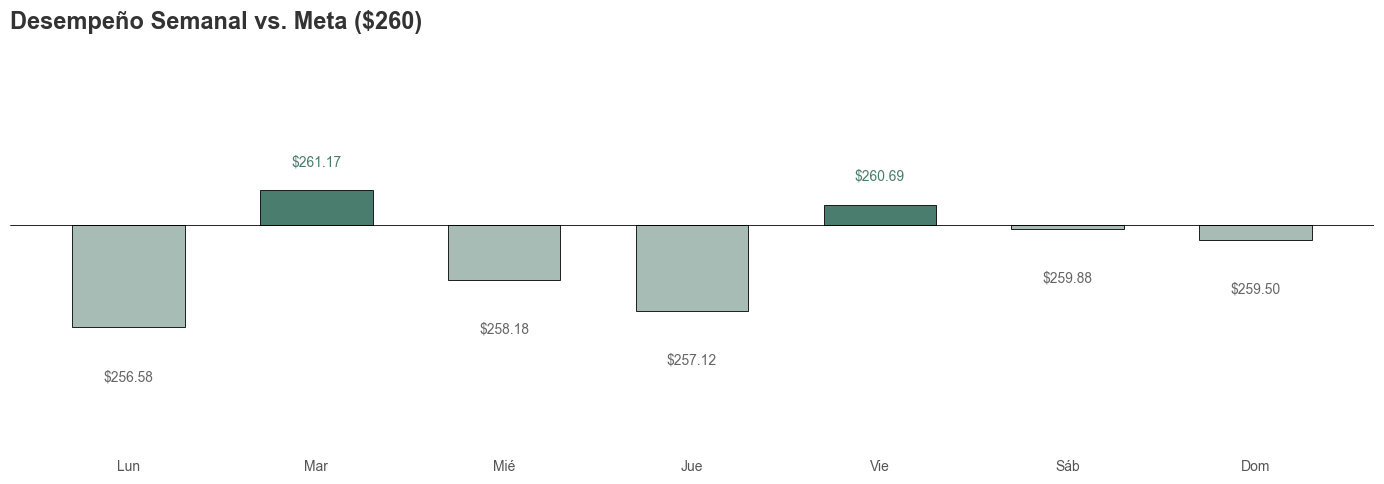

In [ ]:
transactions['timestamp'] = pd.to_datetime(transactions['timestamp'])

transactions['dia_num'] = transactions['timestamp'].dt.dayofweek

resumen_dia = transactions.groupby('dia_num')['amount'].mean().reset_index()
kpi_valor = 260
resumen_dia['desviacion'] = resumen_dia['amount'] - kpi_valor
dias_nombres = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']


verde_exito = "#4A7D6E"    
verde_neutro = "#A7BCB5"   

plt.figure(figsize=(14,5))
cores = [verde_exito if x >= 0 else verde_neutro for x in resumen_dia['desviacion']]

plt.bar(dias_nombres, resumen_dia['desviacion'], color=cores, width=0.6, linewidth=0.6, edgecolor="#000000")
plt.axhline(y=0, color="#000000", linewidth=0.6)

for i, val in enumerate(resumen_dia['desviacion']):
    """
    Etiquetas de los valores reales
    """
    offset = 0.8 if val >= 0 else -1.8
    color_texto = verde_exito if val >= 0 else "#666666"
    
    plt.text(i, val + offset, f"${resumen_dia['amount'].iloc[i]:.2f}", 
             ha='center', fontsize=10, fontweight='light', color=color_texto)

plt.title("Desempeño Semanal vs. Meta ($260)", 
          fontsize=17, 
          weight='bold', 
          pad=30, 
          loc='left', 
          color="#333333")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False) 
#set_color("#000000")
#ax.spines['bottom'].set_linewidth(0.6)

plt.xticks(fontsize=10, fontweight='light', color="#555555")
plt.yticks([]) 

plt.ylim(resumen_dia['desviacion'].min() - 4, resumen_dia['desviacion'].max() + 4)

plt.tight_layout()
plt.show()

<div style="padding: 20px; border-left: 8px solid #4A7D6E; background-color: #f4f9f7; border-radius: 5px; color: #333333; font-family: 'Arial', sans-serif; line-height: 1.6;"> 
    <h3 style="color: #4A7D6E; margin-top: 0;">💡 Insight: Eficiencia vs. Meta Semanal</h3> 
    Al contrastar el ticket promedio contra nuestro <b>KPI Target de $260</b>, observamos que la operación alcanza su pico de rentabilidad únicamente los días <b>Martes ($261.17)</b> y <b>Viernes ($260.69)</b>. Estos puntos resaltados representan los momentos de mayor eficiencia. El resto de la semana presenta una brecha negativa, sugiriendo la necesidad de implementar estímulos comerciales los lunes y jueves para alinear el consumo con nuestros objetivos.
</div>

<div style="
  border-left: 6px solid #4A7D6E;
  background-color: #4A7D6E;
  color: #080303;
  padding: 8px 16px;
  font-weight: bold;
  font-size: 1.1rem;
  margin-top: 20px;
">
  Tres variables combinadas.
</div>

C:\Users\josemessiasferreira\AppData\Local\Temp\ipykernel_4716\922999706.py:10: UserWarning: 
The palette list has fewer values (5) than needed (19) and will cycle, which may produce an uninterpretable plot.
  ax = sns.lineplot(data=evolucion, x='year', y='amount', hue='user_id',


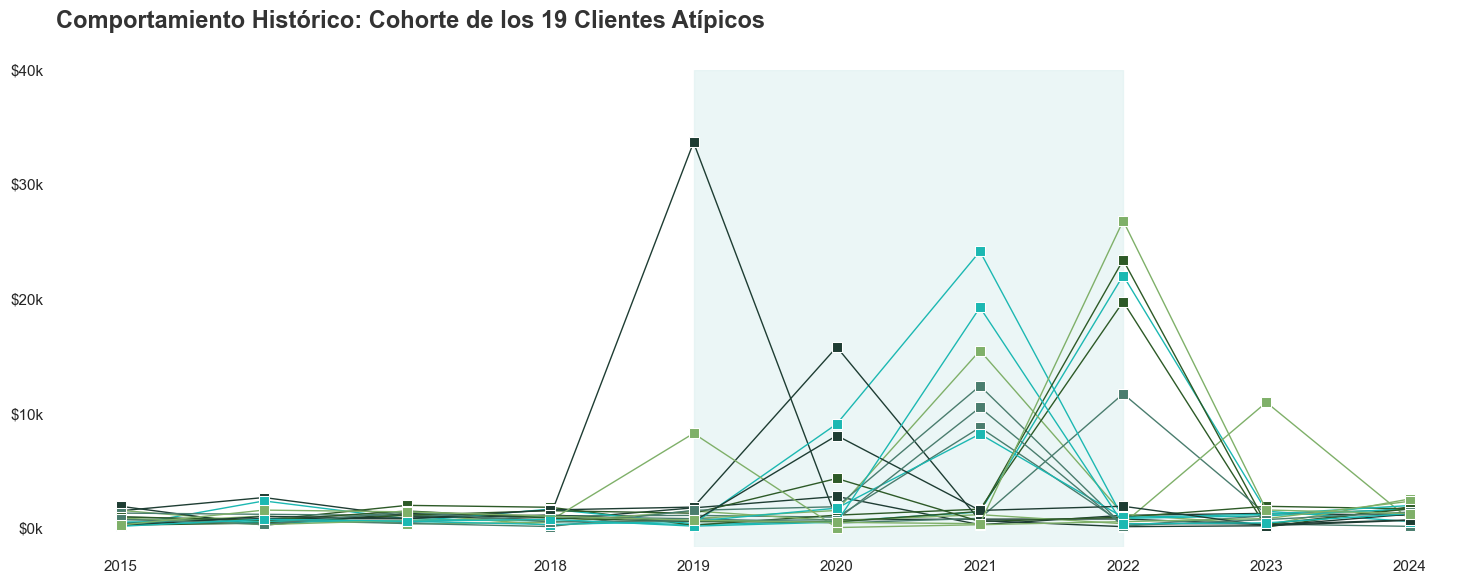

In [ ]:
transactions['year'] = transactions['timestamp'].dt.year

top_19_ids = transactions.groupby('user_id')['amount'].sum().nlargest(19).index
evolucion = transactions[transactions['user_id'].isin(top_19_ids)]
evolucion = evolucion.groupby(['year', 'user_id'])['amount'].sum().reset_index()
colores_pro = ["#1E3D33", "#4A7D6E", "#1CB8B2", "#7FB069", "#2D5A27"]

plt.figure(figsize=(15, 6))
sns.set_theme(style="white")
ax = sns.lineplot(data=evolucion, x='year', y='amount', hue='user_id', 
                  palette=colores_pro, 
                  linewidth=1,  
                  marker='s', 
                  markersize=7,    
                  legend=False);

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}k'))

plt.title("Comportamiento Histórico: Cohorte de los 19 Clientes Atípicos", 
          fontsize=17, weight='bold', color="#333333", loc='left', pad=30)

plt.axvspan(2019, 2022, color="#DFF0F0", alpha=0.60, zorder=0)

plt.xlabel("")
plt.ylabel("")
plt.xticks([2015, 2018, 2019, 2020, 2021, 2022, 2023, 2024])
plt.yticks([0, 10000, 20000, 30000, 40000])
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

<div style="padding: 20px; border-left: 8px solid #4A7D6E; background-color: #f4f9f7; border-radius: 5px; color: #333333; font-family: 'Arial', sans-serif; line-height: 1.6;">
    <h3 style="color: #4A7D6E; margin-top: 0;">📈 Tendencia de Gasto — Clientes Atípicos</h3>
    <p>
Este gráfico muestra que entre 2018 y 2022 vivimos una etapa de grandes movimientos entre nuestros grandes compradores. Tuvimos un pico récord en 2019 ($35k) y una fuerte actividad grupal en 2021-2022. En 2024, el mercado se ha estabilizado y ha vuelto a sus niveles normales.
    </p>
</div>


<div style="
  border-left: 6px solid #4A7D6E;
  background-color: #4A7D6E;
  color: #080303;
  padding: 8px 16px;
  font-weight: bold;
  font-size: 1.1rem;
  margin-top: 20px;
">
  Crea un pairplot
</div>


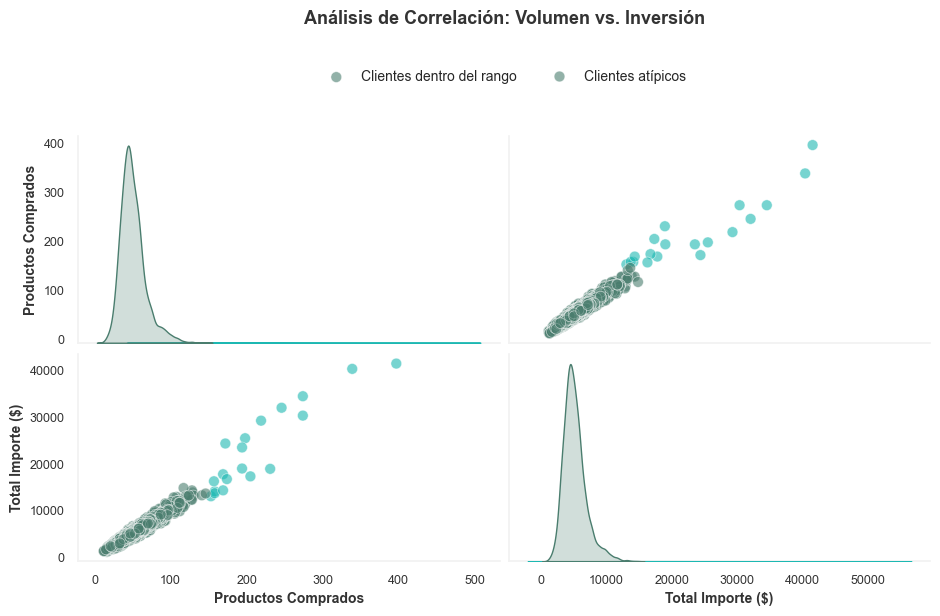

In [ ]:
df_plot = df_users.rename(columns={
    'total_importe': 'Total Importe ($)',
    'productos_comprados': 'Productos Comprados',
    'tipo': 'Segmento'
})


cor_texto = "#333333"      
cinza_fantasma = "#F2F2F2" 

g = sns.pairplot(
    df_plot[['Productos Comprados', 'Total Importe ($)', 'Segmento']], 
    hue='Segmento', 
    palette={'Clientes dentro del rango': "#4A7D6E", 'Clientes atípicos': "#1CB8B2"},
    diag_kind="kde",
    plot_kws={'alpha': 0.6, 's': 60, 'edgecolor': 'white', 'linewidth': 0.5},
    height=2.8,    
    aspect=1.6     
)

g._legend.remove()
posicao_central = 0.5 

g.fig.text(posicao_central, 1.08, "Análisis de Correlación: Volumen vs. Inversión", 
            fontsize=13, weight='bold', color=cor_texto, ha='center')

g.fig.legend(labels=['Clientes dentro del rango', 'Clientes atípicos'], 
             loc='upper center', 
             bbox_to_anchor=(posicao_central, 1.02), 
             ncol=2, frameon=False, fontsize=10)

for ax in g.axes.flatten():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), fontsize=10, fontweight='bold', color=cor_texto)
        ax.set_ylabel(ax.get_ylabel(), fontsize=10, fontweight='bold', color=cor_texto)
        ax.tick_params(axis='both', colors=cor_texto, labelsize=9)
        
        ax.spines['left'].set_color(cinza_fantasma)
        ax.spines['bottom'].set_color(cinza_fantasma)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.subplots_adjust(top=0.88, bottom=0.12, left=0.12, right=0.88)

plt.show() 

<div style="padding: 20px; border-left: 8px solid #4A7D6E; background-color: #f4f9f7; border-radius: 5px; color: #333333; font-family: 'Arial', sans-serif; line-height: 1.6;">
    <h3 style="color: #4A7D6E; margin-top: 0;">📊 Clientes Atípicos: Oportunidad y Salud del Negocio</h3>
    <p>
        Como bien indica el análisis visual, los clientes atípicos operan bajo una lógica de oportunidad: 
        <b>grandes inversiones seguidas de periodos de inactividad</b>.
    </p>
    <p>
        Esta 'irregularidad' es, en realidad, una señal de salud para el negocio, pues demuestra que 
        <b>el crecimiento estructural no depende de eventos fortuitos</b>, sino de la base sólida de 
        clientes recurrentes.
    </p>
</div>


<div style="
  width: 100%;
  background-color: #0A2A43;
  color: white;
  padding: 16px 24px;
  box-sizing: border-box;
  font-weight: bold;
  font-size: 1.4rem;
">
  Nivel 2
</div>


Representa la correlación de algunas variables e interpreta los resultados según tus datos.

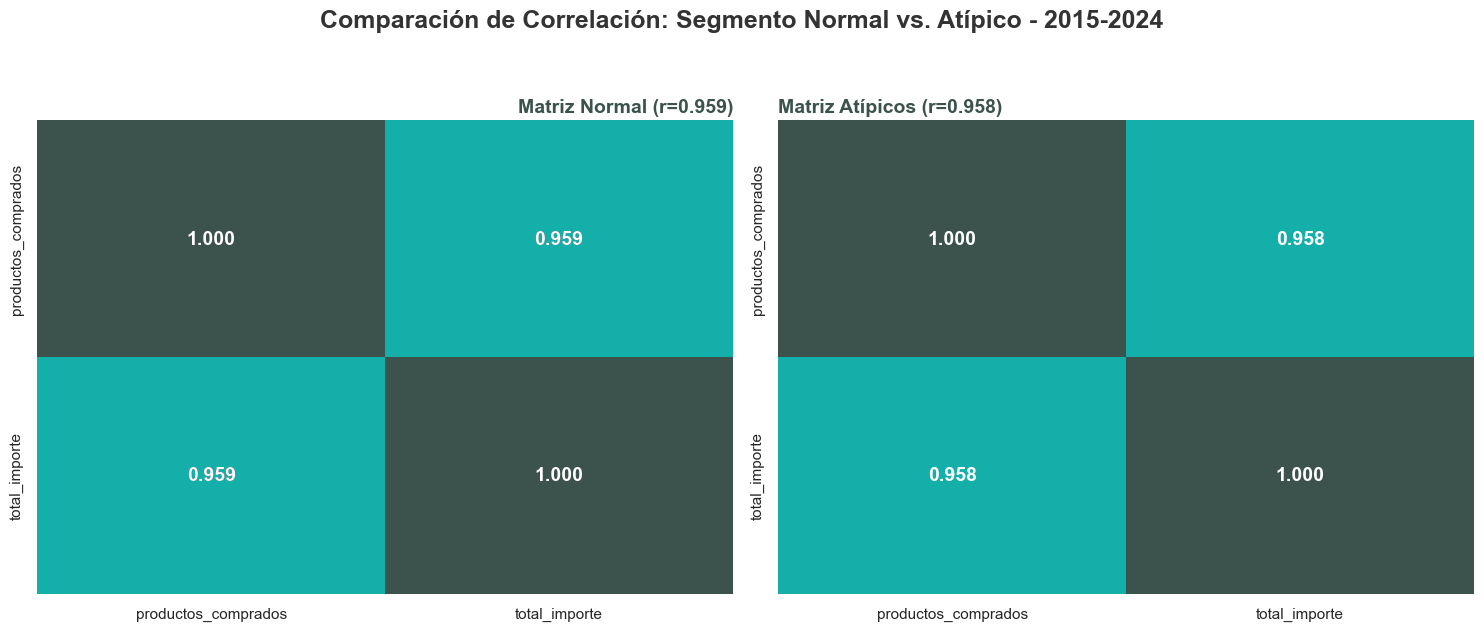

In [ ]:
colores = ["#3B534C", "#15AFAA", "#F2F2F2", "#333333"]

mi_cmap = LinearSegmentedColormap.from_list("mi_paleta", [colores[1], colores[0]]) #degradado suave

media = df_users['total_importe'].mean()
desviacion = df_users['total_importe'].std()
limite_superior = media + (2 * desviacion) # atipicos basados en la media + 2 veces la std dev.

df_users['segmento'] = np.where(df_users['total_importe'] > limite_superior, 'Atípico', 'Normal') 

df_normal = df_users[df_users['segmento'] == 'Normal']
corr_n = df_normal[['productos_comprados', 'total_importe']].corr().iloc[0,1]

df_atipico = df_users[df_users['segmento'] == 'Atípico']
corr_a = df_atipico[['productos_comprados', 'total_importe']].corr().iloc[0,1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(df_normal[['productos_comprados', 'total_importe']].corr(), 
            annot=True, fmt=".3f", cmap=mi_cmap, ax=ax1, cbar=False,
            annot_kws={"size": 14, "weight": "bold", "color": colores[3]})

ax1.set_title(f'Matriz Normal (r={corr_n:.3f})', fontsize=14, weight='bold', color=colores[0], loc='right')
ax2.set_title(f'Matriz Atípicos (r={corr_a:.3f})', fontsize=14, weight='bold', color=colores[0], loc='left')

sns.heatmap(df_normal[['productos_comprados', 'total_importe']].corr(), 
            annot=True, fmt=".3f", cmap=mi_cmap, ax=ax1, cbar=False,
            # cambia [colores] por white
            annot_kws={"size": 14, "weight": "bold", "color": "white"}) 

sns.heatmap(df_atipico[['productos_comprados', 'total_importe']].corr(), 
            annot=True, fmt=".3f", cmap=mi_cmap, ax=ax2, cbar=False,
            # cambia [colores] por white
            annot_kws={"size": 14, "weight": "bold", "color": "white"})

plt.suptitle("Comparación de Correlación: Segmento Normal vs. Atípico - 2015-2024", 
             fontsize=18, weight='bold', color=colores[3], y=1.05)

plt.tight_layout()
plt.show()

<div style="padding: 20px; border-left: 8px solid #4A7D6E; background-color: #f4f9f7; border-radius: 5px; color: #333333; font-family: 'Arial', sans-serif; line-height: 1.6;">
    <h3 style="color: #4A7D6E; margin-top: 0;">📊 Clientes Atípicos: Oportunidad y Salud del Negocio</h3>
    <p>
        Hemos analizado si el comportamiento de nuestros clientes cambia al aumentar el volumen de gasto.<br> Los resultados son contundentes: la correlación se mantiene estable en un $95.8\%$, lo que demuestra que nuestra estructura <br>comercial es robusta y que los clientes de alto valor (Atípicos) operan bajo la misma lógica predecible que el mercado general.
    </p>
</div>


1. Transfiere todas las visualizaciones del Nivel 1 a Power BI utilizando scripts de Python.

Recuerda: cuando cargues tus dataframes en Power BI, asegúrate de incluir una columna identificadora o una combinación de columnas que garantice la unicidad de cada registro. Por defecto, Power BI elimina duplicados y podrías perder información.

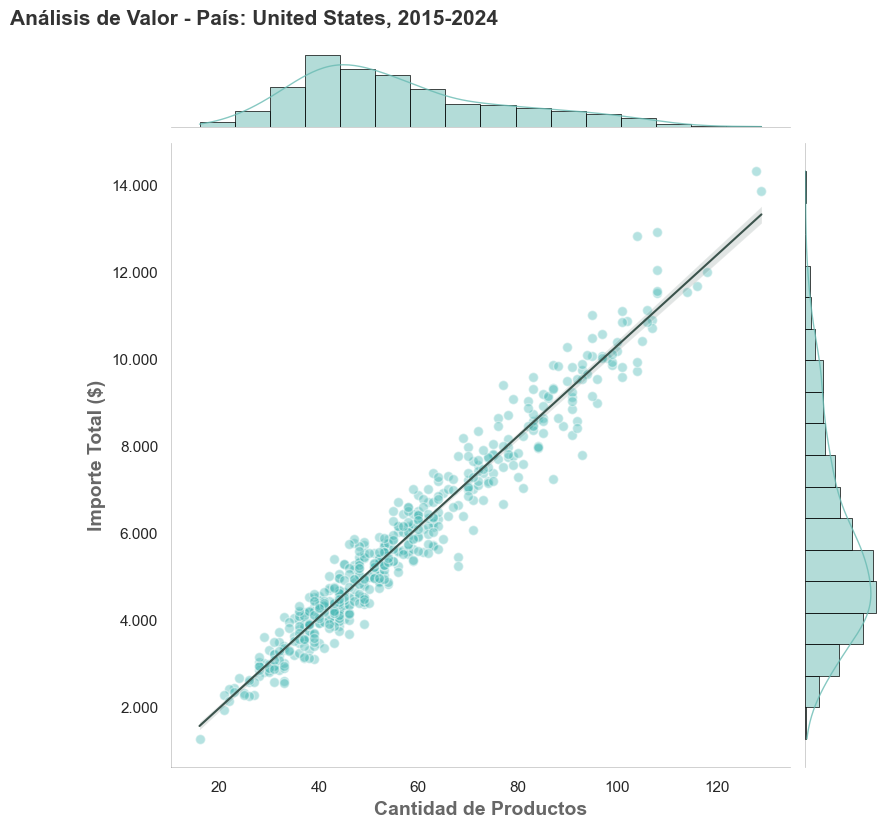

In [ ]:
pais_objetivo = 'United States'
df_pais = df_users[df_users['country'] == pais_objetivo]

colores = ["#3B534C", "#48B8B5", "#F2F2F2", "#333333"]

g = sns.jointplot(
    data=df_pais, 
    x='productos_comprados', 
    y='total_importe',
    kind="reg",
    color=colores[1],
    height=8,        
    ratio=7,          
    scatter_kws={'alpha':0.4, 's':50, 'edgecolor':'white'},
    line_kws={'color':colores[0], 'linewidth': 1.5},
    # Ajuste de marginales: añadimos edgecolor y linewidth para las barras
    marginal_kws={
        'kde': True, 
        'line_kws': {'linewidth': 1, 'alpha': 0.8}, 
        'color': '#69BBB3',
        'edgecolor': 'black',  
        'linewidth': 0.5       
    }
)

# manuel setting
for ax in [g.ax_joint, g.ax_marg_x, g.ax_marg_y]:
    for side in ['top', 'bottom', 'left', 'right']:
        ax.spines[side].set_linewidth(0.5)  
        ax.spines[side].set_alpha(0.3)     


g.ax_joint.grid(False)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))


g.fig.suptitle(f"Análisis de Valor - País: {pais_objetivo}, 2015-2024", 
               fontsize=15, weight='bold', color=colores[3], y=1.03, ha='right')

g.set_axis_labels('Cantidad de Productos', 'Importe Total ($)', 
                  fontsize=14, fontweight='bold', alpha=0.7)

plt.show()

<div style="padding: 20px; border-left: 8px solid #4A7D6E; background-color: #f4f9f7; border-radius: 5px; color: #333333; font-family: 'Arial', sans-serif; line-height: 1.6;">
    <h3 style="color: #4A7D6E; margin-top: 0;">📊 Clientes Atípicos: Oportunidad y Salud del Negocio</h3>
    <p>
    Tras un análisis de las transaciones globales, los resultados confirman que el éxito financiero de la compañía no es producto del azar, sino de una consistencia comercial. Mientras que el Histograma de Transacciones muestra una base de operaciones sólida con una media de $259.02, el Análisis de Valor en United States destaca como el referente de eficiencia, presentando una correlación casi perfecta entre volumen e ingresos que blinda nuestros márgenes ante pedidos a gran escala. <br>Sin embargo, el hallazgo más disruptivo reside en la Cohorte de Clientes Atípicos: el seguimiento histórico revela que este segmento crítico despertó orgánicamente a partir de 2019, multiplicando su valor sin romper la estructura de precios establecida. Esta combinación de estabilidad operativa en mercados maduros y la capacidad de cultivar nichos de alto valor nos posiciona con una ventaja competitiva clara: un modelo de negocio altamente predecible, escalable y con una elasticidad de precio que garantiza la rentabilidad en el largo plazo.
    </p>
</div>

<div style="
  width: 100%;
  background-color: #0A2A43;
  color: white;
  padding: 16px 24px;
  box-sizing: border-box;
  font-weight: bold;
  font-size: 1.4rem;
">
  Nivel 3
</div>


1. Transfiere todas las visualizaciones del Nivel 1 a Power BI utilizando scripts de Python.

Recuerda: cuando cargues tus dataframes en Power BI, asegúrate de incluir una columna identificadora o una combinación de columnas que garantice la unicidad de cada registro. Por defecto, Power BI elimina duplicados y podrías perder información.